# Lõputöö

### Teegid

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns
import time

### Andmete laadimine

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/My Drive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
filename_sagedused = "rod_1_3_crack_2_frequencies.txt"
df_sagedused = pd.read_csv(filename_sagedused, sep=r"\s+")
df_sagedused.head()
len(df_sagedused)

5184

In [4]:
filename_haari = "rod_1_3_crack_32_haar_wavelet_coefficients.txt"
df_haari = pd.read_csv(filename_haari, sep=r"\s+", skiprows=2)
df_haari.head()
len(df_haari)


5184

### Tunnuste ja targetite eraldamine

In [5]:
# Veergude nimed
df_sagedused.columns = ["L1_L", "L2_L", "a1_h", "a2_h"] + [f"fr_{i}" for i in range(1, 11)]
df_haari.columns = ["L1_L", "L2_L", "a1_h", "a2_h", "f1"] + [f"haar_{i}" for i in range(1, 33)]

# Teise prao absoluutne asukoht
df_sagedused["L2_L"] = df_sagedused["L1_L"] + df_sagedused["L2_L"]
df_haari["L2_L"] = df_haari["L1_L"] + df_haari["L2_L"]

# Kontrollin, et sihtväärtused oleks samas järjekorras
print(df_sagedused.iloc[:, :4].equals(df_haari.iloc[:, :4]))

X_sagedused = df_sagedused.iloc[:, 4:]
X_haari = df_haari.iloc[:, 5:]
X_combined = df_haari.iloc[:, 4:]

y = df_sagedused.iloc[:, :4]


True


In [6]:
# Ühed ja samad indeksid kõigile andmestikele
indices = list(range(len(y)))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

print(len(X_sagedused))
print(len(X_haari))
print(len(X_combined))
print(len(y))

5184
5184
5184
5184


In [7]:
X_train_s = X_sagedused.iloc[train_idx]
X_test_s = X_sagedused.iloc[test_idx]

X_train_h = X_haari.iloc[train_idx]
X_test_h = X_haari.iloc[test_idx]

X_train_c = X_combined.iloc[train_idx]
X_test_c = X_combined.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [8]:
# Sageduste skaleerimine
scaler_s = MinMaxScaler()

X_train_s = pd.DataFrame(
    scaler_s.fit_transform(X_train_s),
    columns=X_train_s.columns,
    index=X_train_s.index
)

X_test_s = pd.DataFrame(
    scaler_s.transform(X_test_s),
    columns=X_test_s.columns,
    index=X_test_s.index
)

In [9]:
# Kombineeritud andmestikus f1 skaleerimine
scaler_c = MinMaxScaler()

X_train_c = pd.DataFrame(
    scaler_c.fit_transform(X_train_c),
    columns=X_train_c.columns,
    index=X_train_c.index
)

X_test_c = pd.DataFrame(
    scaler_c.transform(X_test_c),
    columns=X_test_c.columns,
    index=X_test_c.index
)

### Mudeli testimise meetodid

In [10]:
# Funktsioon treenib mudeli ühe sihtmuutuja jaoks ja arvutab hindamismõõdikud.
def test(model_name, model, X_train, y_train, X_test, y_test, target_name):

  print(model_name)
  print("Target: " + target_name)

  y_train = y_train[target_name]
  y_test = y_test[target_name]

  start_time = time.time()

  model.fit(X_train, y_train)
  predictions = model.predict(X_test)

  end_time = time.time()
  running_time = end_time - start_time

  # Mean Absolute Error
  mae = mean_absolute_error(y_test, predictions)
  print("Mean Absolute Error:", mae)

  # Root Mean Squared Error
  rmse = np.sqrt(mean_squared_error(y_test, predictions))
  print("Root Mean Squared Error:", rmse)

  # R²
  r2 = r2_score(y_test, predictions)
  print("R²:", r2)

  print("Running time:", running_time)

  print()

  return [model_name, target_name, mae, rmse, r2, running_time]


Parameetrite testimisel ei ole hindamiskriteeriumite välja printimine vajalik, seega tegin selleks sama meetodi ilma printideta.

In [11]:
def test_vaikne(model, X_train, y_train, X_test, y_test, target_name):
    y_train_target = y_train[target_name]
    y_test_target = y_test[target_name]

    model.fit(X_train, y_train_target)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test_target, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_target, predictions))
    r2 = r2_score(y_test_target, predictions)

    return [mae, rmse, r2]

In [12]:
# Sihtmuutujad, mida mudelid ennustavad.
targets = ["L1_L", "L2_L", "a1_h", "a2_h"]

#Parimate parameetrite leidmine

## XGBoosti parameetrid

Leian XGBoosti jaoks parimad parameetrid n_estimators, learning_rate ja max_depth.

In [ ]:
param_results = []

n_estimators_list = [200, 300, 400]
learning_rate_list = [0.05, 0.1, 0.2]
max_depth_list = [7, 8, 9]

datasets = [
    ["sagedused", X_train_s, y_train, X_test_s, y_test],
    ["haari", X_train_h, y_train, X_test_h, y_test],
    ["combined", X_train_c, y_train, X_test_c, y_test]
]

for dataset_name, X_train, y_train, X_test, y_test in datasets:
    for n_estimators in n_estimators_list:
        for learning_rate in learning_rate_list:
            for max_depth in max_depth_list:

              all_results = []

              for target in targets:
                  model = XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42)
                  mae, rmse, r2 = test_vaikne(model, X_train, y_train, X_test, y_test, target)
                  all_results.append([mae, rmse, r2])

              results_df = pd.DataFrame(all_results, columns=["MAE", "RMSE", "R2"])

              param_results.append([
                  dataset_name,
                  n_estimators,
                  learning_rate,
                  max_depth,
                  results_df["MAE"].mean(),
                  results_df["RMSE"].mean(),
                  results_df["R2"].mean()
              ])


param_table = pd.DataFrame(param_results, columns=["Andmestik", "n_estimators", "learning_rate", "max_depth", "MAE", "RMSE", "R2"])
param_table = param_table.sort_values(by="R2", ascending=False)

param_table

,Andmestik,n_estimators,learning_rate,max_depth,MAE,RMSE,R2
48,haari,400,0.10,7,0.008986,0.020132,0.977410
39,haari,300,0.10,7,0.009085,0.020261,0.977109
30,haari,200,0.10,7,0.009357,0.020623,0.976253
45,haari,400,0.05,7,0.009306,0.020735,0.975975
72,combined,400,0.05,7,0.009230,0.020776,0.975711
...,...,...,...,...,...,...,...
0,sagedused,200,0.05,7,0.038639,0.062477,0.785208
6,sagedused,200,0.20,7,0.037272,0.062470,0.785122
8,sagedused,200,0.20,9,0.036075,0.062642,0.784439
17,sagedused,300,0.20,9,0.036075,0.062642,0.784439


## Random Forest

Leian Random Forest jaoks parima n_estimators parameetri.

In [ ]:
rf_results = []

n_estimators_list = [50, 100, 200, 300, 500]

datasets = [
    ["sagedused", X_train_s, y_train, X_test_s, y_test],
    ["haari", X_train_h, y_train, X_test_h, y_test],
    ["combined", X_train_c, y_train, X_test_c, y_test]
]

for dataset_name, X_train, y_train, X_test, y_test in datasets:
    for n_estimators in n_estimators_list:

        all_results = []

        for target in targets:
            rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
            mae, rmse, r2 = test_vaikne(rf_model, X_train, y_train, X_test, y_test, target)
            all_results.append([mae, rmse, r2])

        results_df = pd.DataFrame(all_results, columns=["MAE", "RMSE", "R2"])

        rf_results.append([
            dataset_name,
            n_estimators,
            results_df["MAE"].mean(),
            results_df["RMSE"].mean(),
            results_df["R2"].mean()
        ])

rf_param_table = pd.DataFrame(rf_results, columns=["Andmestik", "n_estimators", "MAE", "RMSE", "R2"])
rf_param_table = rf_param_table.sort_values(by="R2", ascending=False)

rf_param_table

,Andmestik,n_estimators,MAE,RMSE,R2
9,haari,500,0.009230,0.022732,0.970214
8,haari,300,0.009265,0.022793,0.970096
7,haari,200,0.009342,0.022959,0.969623
6,haari,100,0.009412,0.023123,0.969256
5,haari,50,0.009611,0.023466,0.968529
14,combined,500,0.009499,0.023257,0.968506
13,combined,300,0.009538,0.023331,0.968347
12,combined,200,0.009589,0.023405,0.968213
11,combined,100,0.009771,0.023668,0.967630
10,combined,50,0.009950,0.023874,0.967376


# Sageduste järgi ennustamine

In [14]:
all_results = []

## Juhumets

In [15]:
for target in targets:
    rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
    result = test("Random Forest - sagedused", rf_model, X_train_s, y_train, X_test_s, y_test, target)
    all_results.append(result)

Random Forest - sagedused
Target: L1_L
Mean Absolute Error: 0.03419652844744478
Root Mean Squared Error: 0.0536569317603999
R²: 0.7897127843605245
Running time: 28.056292295455933

Random Forest - sagedused
Target: L2_L
Mean Absolute Error: 0.0472914175506267
Root Mean Squared Error: 0.07675016036910107
R²: 0.7860916079518059
Running time: 25.69084358215332

Random Forest - sagedused
Target: a1_h
Mean Absolute Error: 0.0344741562198652
Root Mean Squared Error: 0.05849213259660766
R²: 0.78955387263096
Running time: 25.943488121032715

Random Forest - sagedused
Target: a2_h
Mean Absolute Error: 0.032590646094503635
Root Mean Squared Error: 0.056601259309739846
R²: 0.8064729682529517
Running time: 25.59706735610962



## Lineaarne regressioon

In [16]:
for target in targets:
    lr_model = LinearRegression()
    result = test("Linear Regression - sagedused", lr_model, X_train_s, y_train, X_test_s, y_test, target)
    all_results.append(result)

Linear Regression - sagedused
Target: L1_L
Mean Absolute Error: 0.06414241725443197
Root Mean Squared Error: 0.07819361096780655
R²: 0.5534154037388903
Running time: 0.032402753829956055

Linear Regression - sagedused
Target: L2_L
Mean Absolute Error: 0.0912495637788036
Root Mean Squared Error: 0.11346914997121096
R²: 0.5324534649402439
Running time: 0.004322528839111328

Linear Regression - sagedused
Target: a1_h
Mean Absolute Error: 0.06405134190187503
Root Mean Squared Error: 0.07905599027069965
R²: 0.6155714860641146
Running time: 0.004576206207275391

Linear Regression - sagedused
Target: a2_h
Mean Absolute Error: 0.06262299931347944
Root Mean Squared Error: 0.07885790000731158
R²: 0.6243530533520947
Running time: 0.00419926643371582



## Tugivektormasin

In [17]:
for target in targets:
  svm_model = Pipeline([('scaler', MinMaxScaler()),('svm', SVR())])
  result = test("SVR - sagedused", svm_model, X_train_s, y_train, X_test_s, y_test, target)
  all_results.append(result)

SVR - sagedused
Target: L1_L
Mean Absolute Error: 0.05575029223663246
Root Mean Squared Error: 0.06708222687599066
R²: 0.6713178320230224
Running time: 0.49066972732543945

SVR - sagedused
Target: L2_L
Mean Absolute Error: 0.06732716726675664
Root Mean Squared Error: 0.08589814943508756
R²: 0.7320604305592481
Running time: 0.3430454730987549

SVR - sagedused
Target: a1_h
Mean Absolute Error: 0.06258400075281452
Root Mean Squared Error: 0.0738143457846562
R²: 0.6648589881576
Running time: 0.1928114891052246

SVR - sagedused
Target: a2_h
Mean Absolute Error: 0.0618228471901814
Root Mean Squared Error: 0.07376240298304418
R²: 0.6713303814098606
Running time: 0.4847381114959717



## XGBoost


In [18]:
for target in targets:
  xgb_model = XGBRegressor(n_estimators = 400, learning_rate = 0.1, max_depth = 7, random_state = 42)
  result = test("XGBoost - sagedused", xgb_model, X_train_s, y_train, X_test_s, y_test, target)
  all_results.append(result)

XGBoost - sagedused
Target: L1_L
Mean Absolute Error: 0.03339430333448353
Root Mean Squared Error: 0.053272637923040406
R²: 0.7927141744200681
Running time: 1.9380595684051514

XGBoost - sagedused
Target: L2_L
Mean Absolute Error: 0.047435472682908736
Root Mean Squared Error: 0.07651556775698004
R²: 0.787397263515528
Running time: 1.8361303806304932

XGBoost - sagedused
Target: a1_h
Mean Absolute Error: 0.03260566913661985
Root Mean Squared Error: 0.05782184362655201
R²: 0.7943494400612728
Running time: 2.945302963256836

XGBoost - sagedused
Target: a2_h
Mean Absolute Error: 0.03119716233822626
Root Mean Squared Error: 0.057579634283422866
R²: 0.7997247639783938
Running time: 4.672036170959473



# Haari kordajate järgi ennustamine


## Juhumets

In [19]:
for target in targets:
    rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
    result = test("Random Forest - haari", rf_model, X_train_h, y_train, X_test_h, y_test, target)
    all_results.append(result)

Random Forest - haari
Target: L1_L
Mean Absolute Error: 0.0032119575699143593
Root Mean Squared Error: 0.012174465429168436
R²: 0.9891741750037356
Running time: 61.84787344932556

Random Forest - haari
Target: L2_L
Mean Absolute Error: 0.008616972034716551
Root Mean Squared Error: 0.02689073967789473
R²: 0.9737412083806655
Running time: 70.61404228210449

Random Forest - haari
Target: a1_h
Mean Absolute Error: 0.010483510125362054
Root Mean Squared Error: 0.02487871602574548
R²: 0.9619283278006635
Running time: 72.43904852867126

Random Forest - haari
Target: a2_h
Mean Absolute Error: 0.014607328833172915
Root Mean Squared Error: 0.026985052114244516
R²: 0.9560118223623562
Running time: 79.88831448554993



## Lineaarne regressioon

In [20]:
for target in targets:
    lr_model = LinearRegression()
    result = test("Linear Regression - haari", lr_model, X_train_h, y_train, X_test_h, y_test, target)
    all_results.append(result)

Linear Regression - haari
Target: L1_L
Mean Absolute Error: 0.048886301125893365
Root Mean Squared Error: 0.06244781451848007
R²: 0.7151634684714971
Running time: 0.011825799942016602

Linear Regression - haari
Target: L2_L
Mean Absolute Error: 0.07185372562506162
Root Mean Squared Error: 0.09236165344141437
R²: 0.6902205260963253
Running time: 0.007954835891723633

Linear Regression - haari
Target: a1_h
Mean Absolute Error: 0.05812160686595765
Root Mean Squared Error: 0.07403745402938718
R²: 0.6628299591228859
Running time: 0.008870601654052734

Linear Regression - haari
Target: a2_h
Mean Absolute Error: 0.052435918081172386
Root Mean Squared Error: 0.06881190344495033
R²: 0.7139667040390184
Running time: 0.007769346237182617



## Tugivektormasin

In [21]:
for target in targets:
  svm_model = Pipeline([('scaler', StandardScaler()),('svm', SVR())])
  result = test("SVR - haari", svm_model, X_train_h, y_train, X_test_h, y_test, target)
  all_results.append(result)

SVR - haari
Target: L1_L
Mean Absolute Error: 0.05257502644819546
Root Mean Squared Error: 0.06231119993853227
R²: 0.7164083562036565
Running time: 0.1966381072998047

SVR - haari
Target: L2_L
Mean Absolute Error: 0.058656789630274105
Root Mean Squared Error: 0.07081108631697647
R²: 0.8179160131979302
Running time: 0.2432847023010254

SVR - haari
Target: a1_h
Mean Absolute Error: 0.0517579472205673
Root Mean Squared Error: 0.06378386475059479
R²: 0.7497536873085198
Running time: 0.16092348098754883

SVR - haari
Target: a2_h
Mean Absolute Error: 0.06212017392532908
Root Mean Squared Error: 0.0711278363527825
R²: 0.6943892377953236
Running time: 0.16695618629455566



## XGBoost

In [22]:
for target in targets:
  xgb_model = XGBRegressor(n_estimators = 400, learning_rate = 0.1, max_depth = 7, random_state = 42)
  result = test("XGBoost - haari", xgb_model, X_train_h, y_train, X_test_h, y_test, target)
  all_results.append(result)

XGBoost - haari
Target: L1_L
Mean Absolute Error: 0.004451857221276
Root Mean Squared Error: 0.012968665137935915
R²: 0.9877156621031683
Running time: 3.21598744392395

XGBoost - haari
Target: L2_L
Mean Absolute Error: 0.010514248969354876
Root Mean Squared Error: 0.02478714673653944
R²: 0.9776888315369213
Running time: 8.485016584396362

XGBoost - haari
Target: a1_h
Mean Absolute Error: 0.008894864407469826
Root Mean Squared Error: 0.020878523192983386
R²: 0.9731869894375406
Running time: 5.031451940536499

XGBoost - haari
Target: a2_h
Mean Absolute Error: 0.012082462836139573
Root Mean Squared Error: 0.021892927493072808
R²: 0.9710467629939608
Running time: 8.811519622802734



# Kombineeritud sageduste ja haari kordajate järgi ennustamine

## Juhumets

In [23]:
for target in targets:
  rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
  result = test("Random Forest - combined", rf_model, X_train_c, y_train, X_test_c, y_test, target)
  all_results.append(result)

Random Forest - combined
Target: L1_L
Mean Absolute Error: 0.003192960462874848
Root Mean Squared Error: 0.012112658647788266
R²: 0.9892838161128846
Running time: 61.22085952758789

Random Forest - combined
Target: L2_L
Mean Absolute Error: 0.00868408871745518
Root Mean Squared Error: 0.026911584582921578
R²: 0.9737004825268291
Running time: 71.9686987400055

Random Forest - combined
Target: a1_h
Mean Absolute Error: 0.011545226615236605
Root Mean Squared Error: 0.027535765818813618
R²: 0.9533619540920744
Running time: 75.83311820030212

Random Forest - combined
Target: a2_h
Mean Absolute Error: 0.014571745419479573
Root Mean Squared Error: 0.026468951444091404
R²: 0.9576783177238246
Running time: 80.89260792732239



## Lineaarne regressioon

In [24]:
for target in targets:
  lr_model = LinearRegression()
  result = test("Linear Regression - combined", lr_model, X_train_c, y_train, X_test_c, y_test, target)
  all_results.append(result)

Linear Regression - combined
Target: L1_L
Mean Absolute Error: 0.04812652978413767
Root Mean Squared Error: 0.06139976216502004
R²: 0.7246439782701855
Running time: 0.008199214935302734

Linear Regression - combined
Target: L2_L
Mean Absolute Error: 0.07189409514170135
Root Mean Squared Error: 0.09237436088856102
R²: 0.6901352790929558
Running time: 0.007656097412109375

Linear Regression - combined
Target: a1_h
Mean Absolute Error: 0.05063029207368624
Root Mean Squared Error: 0.06850269805866599
R²: 0.7113567667536951
Running time: 0.007809877395629883

Linear Regression - combined
Target: a2_h
Mean Absolute Error: 0.04643893371555997
Root Mean Squared Error: 0.06396508721943252
R²: 0.7528415626381151
Running time: 0.007909774780273438



## Tugivektormasin

In [25]:
for target in targets:
  svm_model = Pipeline([('scaler', StandardScaler()),('svm', SVR())])
  result = test("SVR - combined", svm_model, X_train_c, y_train, X_test_c, y_test, target)
  all_results.append(result)

SVR - combined
Target: L1_L
Mean Absolute Error: 0.05449177285990578
Root Mean Squared Error: 0.06369968100655363
R²: 0.7036289930737007
Running time: 0.1837787628173828

SVR - combined
Target: L2_L
Mean Absolute Error: 0.0586167153332268
Root Mean Squared Error: 0.0707814391619102
R²: 0.8180684509700189
Running time: 0.22624850273132324

SVR - combined
Target: a1_h
Mean Absolute Error: 0.05147835562897771
Root Mean Squared Error: 0.06357255952490272
R²: 0.7514089888565972
Running time: 0.16478800773620605

SVR - combined
Target: a2_h
Mean Absolute Error: 0.06253429142346677
Root Mean Squared Error: 0.0716720874919111
R²: 0.6896944413132332
Running time: 0.25261592864990234



## XGBoost

In [26]:
for target in targets:
  xgb_model = XGBRegressor(n_estimators = 400, learning_rate = 0.1, max_depth = 7, random_state = 42)
  result = test("XGBoost - combined", xgb_model, X_train_c, y_train, X_test_c, y_test, target)
  all_results.append(result)

XGBoost - combined
Target: L1_L
Mean Absolute Error: 0.004471441833239512
Root Mean Squared Error: 0.01266489037677891
R²: 0.9882844125333546
Running time: 6.2715864181518555

XGBoost - combined
Target: L2_L
Mean Absolute Error: 0.010772947767316547
Root Mean Squared Error: 0.025119222878713727
R²: 0.9770870166954859
Running time: 5.0574517250061035

XGBoost - combined
Target: a1_h
Mean Absolute Error: 0.009497820116083786
Root Mean Squared Error: 0.023291259744335227
R²: 0.9666318611551258
Running time: 8.568700313568115

XGBoost - combined
Target: a2_h
Mean Absolute Error: 0.011617349958983083
Root Mean Squared Error: 0.022315287895676283
R²: 0.9699188499305306
Running time: 5.729604244232178



In [27]:
results_df = pd.DataFrame(all_results, columns=["Model", "Target", "MAE", "RMSE", "R2", "Time"])

# Tulemuste võrdlus ja joonised

In [28]:
for target in targets:
    print("Target:", target)
    print(results_df[results_df["Target"] == target].sort_values(by="R2", ascending=False))
    print()

Target: L1_L
                            Model Target       MAE      RMSE        R2  \
32       Random Forest - combined   L1_L  0.003193  0.012113  0.989284   
16          Random Forest - haari   L1_L  0.003212  0.012174  0.989174   
44             XGBoost - combined   L1_L  0.004471  0.012665  0.988284   
28                XGBoost - haari   L1_L  0.004452  0.012969  0.987716   
12            XGBoost - sagedused   L1_L  0.033394  0.053273  0.792714   
0       Random Forest - sagedused   L1_L  0.034197  0.053657  0.789713   
36   Linear Regression - combined   L1_L  0.048127  0.061400  0.724644   
24                    SVR - haari   L1_L  0.052575  0.062311  0.716408   
20      Linear Regression - haari   L1_L  0.048886  0.062448  0.715163   
40                 SVR - combined   L1_L  0.054492  0.063700  0.703629   
8                 SVR - sagedused   L1_L  0.055750  0.067082  0.671318   
4   Linear Regression - sagedused   L1_L  0.064142  0.078194  0.553415   

         Time  
32  61.2

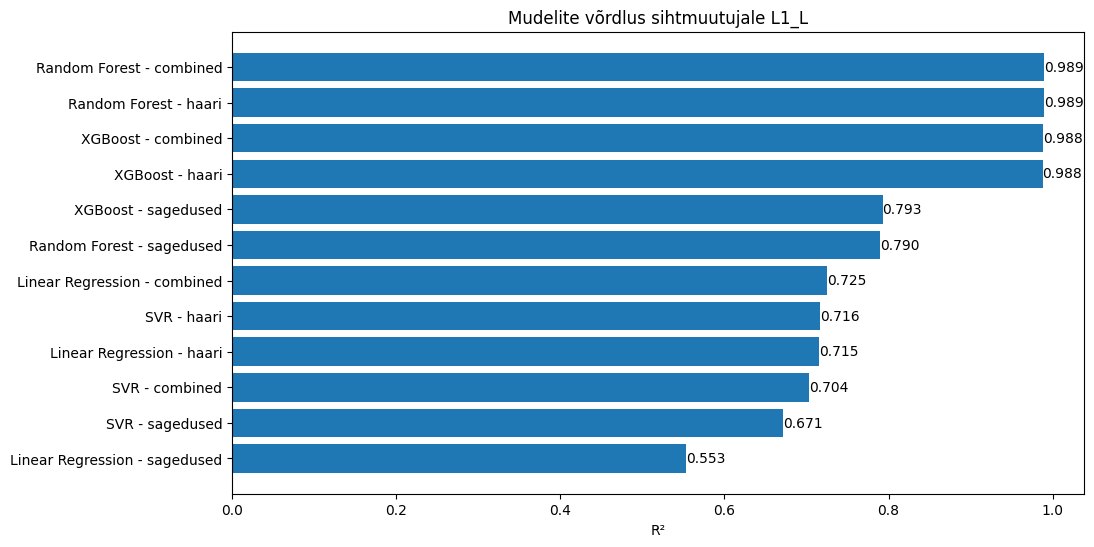

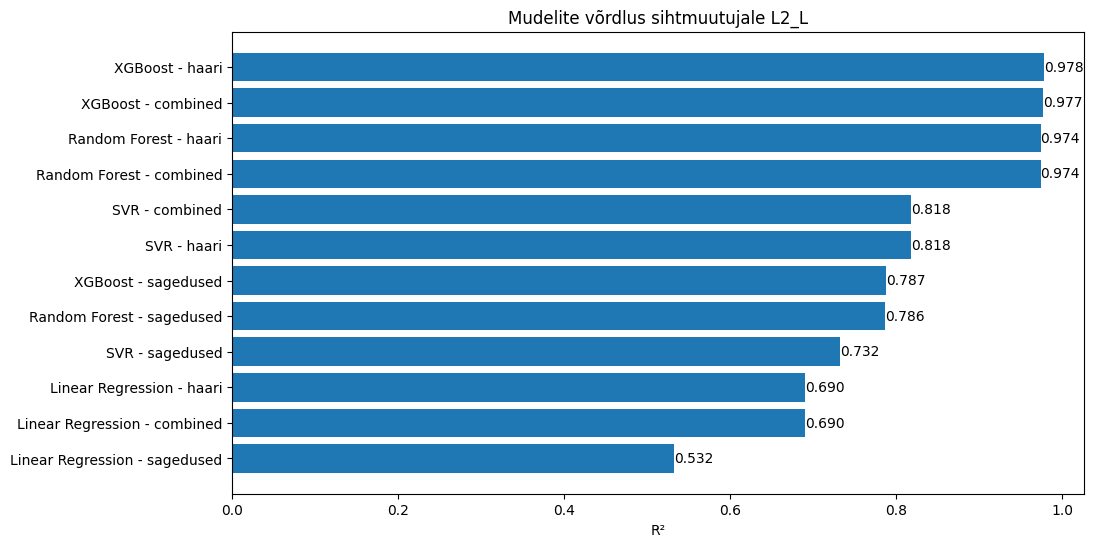

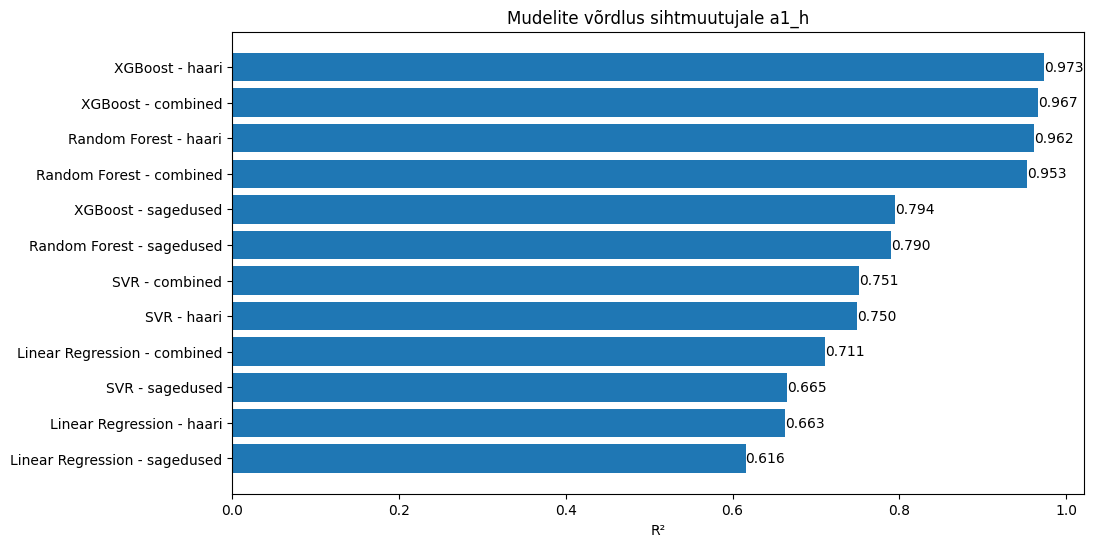

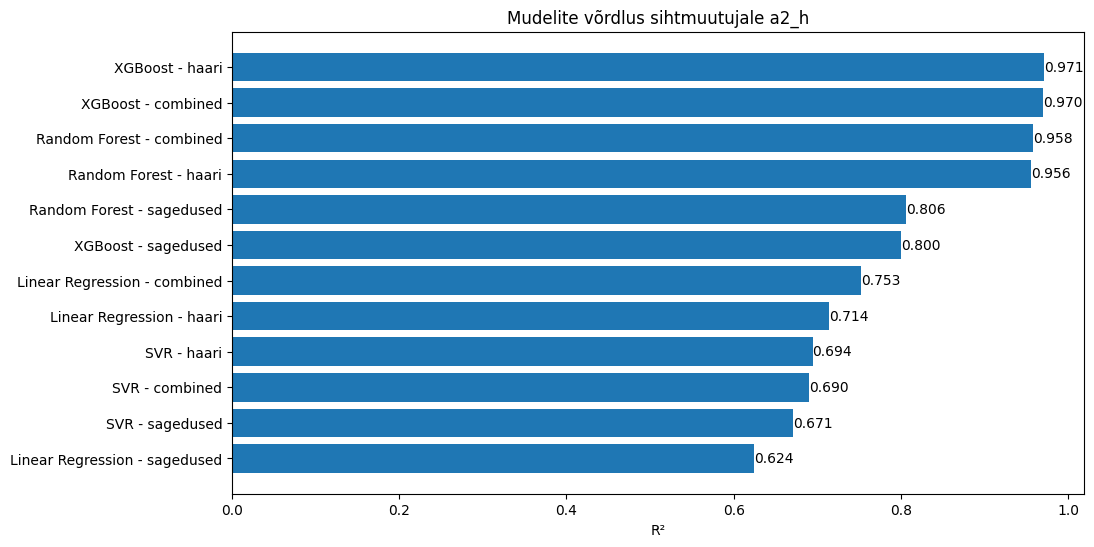

In [29]:
for target in targets:
    df_target = results_df[results_df["Target"] == target].sort_values(by="R2", ascending=False)

    plt.figure(figsize=(11, 6))
    plt.barh(df_target["Model"], df_target["R2"])
    plt.bar_label(plt.gca().containers[0], fmt="%.3f")
    plt.xlabel("R²")
    plt.title(f"Mudelite võrdlus sihtmuutujale {target}")
    plt.gca().invert_yaxis()
    plt.show()

In [30]:
asukoha_tunnused = ["L1_L", "L2_L"]
sugavuse_tunnused = ["a1_h", "a2_h"]

# Asukoha tulemused
asukoha_andmed = results_df[results_df["Target"].isin(asukoha_tunnused)]
asukoha_keskmine = asukoha_andmed.groupby("Model")[["MAE", "RMSE", "R2"]].mean()
asukoha_keskmine = asukoha_keskmine.sort_values(by="R2", ascending=False)

# Sügavuse tulemused
sugavuse_andmed = results_df[results_df["Target"].isin(sugavuse_tunnused)]
sugavuse_keskmine = sugavuse_andmed.groupby("Model")[["MAE", "RMSE", "R2"]].mean()
sugavuse_keskmine = sugavuse_keskmine.sort_values(by="R2", ascending=False)

# Üldine keskmine
uldine_keskmine = results_df.groupby("Model")[["MAE", "RMSE", "R2"]].mean()
uldine_keskmine = uldine_keskmine.sort_values(by="R2", ascending=False)

print("Asukoha ennustamise keskmised tulemused:")
print(asukoha_keskmine.round(5))
print()

print("Sügavuse ennustamise keskmised tulemused:")
print(sugavuse_keskmine.round(5))
print()

print("Üldised keskmised tulemused:")
print(uldine_keskmine.round(5))
print()

print("Parim asukoha jaoks:")
print(asukoha_keskmine.head(1).round(5))
print()

print("Parim sügavuse jaoks:")
print(sugavuse_keskmine.head(1).round(5))
print()

print("Üldiselt parim:")
print(uldine_keskmine.head(1).round(5))

Asukoha ennustamise keskmised tulemused:
                                   MAE     RMSE       R2
Model                                                   
XGBoost - haari                0.00748  0.01888  0.98270
XGBoost - combined             0.00762  0.01889  0.98269
Random Forest - combined       0.00594  0.01951  0.98149
Random Forest - haari          0.00591  0.01953  0.98146
XGBoost - sagedused            0.04041  0.06489  0.79006
Random Forest - sagedused      0.04074  0.06520  0.78790
SVR - haari                    0.05562  0.06656  0.76716
SVR - combined                 0.05655  0.06724  0.76085
Linear Regression - combined   0.06001  0.07689  0.70739
Linear Regression - haari      0.06037  0.07740  0.70269
SVR - sagedused                0.06154  0.07649  0.70169
Linear Regression - sagedused  0.07770  0.09583  0.54293

Sügavuse ennustamise keskmised tulemused:
                                   MAE     RMSE       R2
Model                                                   
XGBo

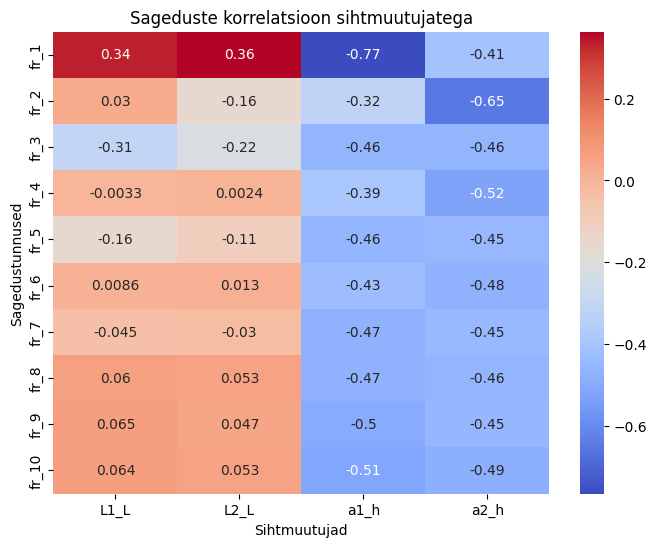

In [31]:
corr_s = pd.concat([X_sagedused, y], axis=1).corr()

corr_s_targets = corr_s.loc[X_sagedused.columns, y.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_s_targets, annot=True, cmap="coolwarm")
plt.title("Sageduste korrelatsioon sihtmuutujatega")
plt.xlabel("Sihtmuutujad")
plt.ylabel("Sagedustunnused")
plt.show()

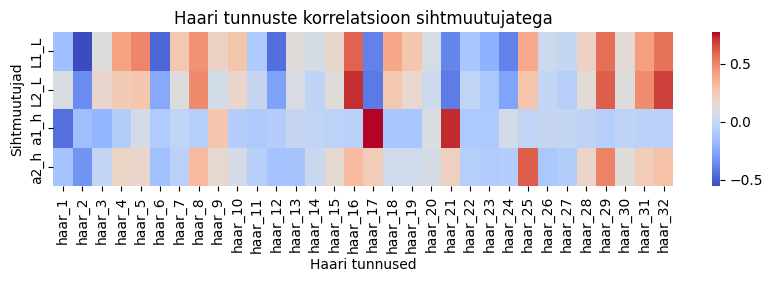

In [32]:
corr_h = pd.concat([X_haari, y], axis=1).corr()

corr_h_targets = corr_h.loc[X_haari.columns, y.columns]

plt.figure(figsize=(10, 2))
sns.heatmap(corr_h_targets.T, cmap="coolwarm")
plt.title("Haari tunnuste korrelatsioon sihtmuutujatega")
plt.xlabel("Haari tunnused")
plt.ylabel("Sihtmuutujad")
plt.show()